<div dir="rtl">

# DBSCAN بخش ۲: تنظیم eps

در این نوت‌بوک min_samples رو ثابت نگه داریم و eps را تغییر می‌دهیم تا اثر خالص eps دیده بشه و بازه‌ای پیدا کنیم که حدود ۳ خوشه معنادار بده
داده دقیقا مثل نوت‌بوک ۱ آماده شده و همان نمونه ۵۰ هزارتایی گرفته شده تا نتایج قابل مقایسه باشن

</div>

<div dir="rtl">

## ۱. آماده‌سازی داده

همان مراحل نوت‌بوک ۱ یعنی ساخت قیمت یکپارچه و حذف خالی‌ها و قیمت‌های الکی و پرت‌ها و مقیاس‌بندی و نمونه ۵۰ هزارتایی. به خاطر random_state ثابت دقیقا همان نمونه انتخاب میشه و خیالمون راحته 

</div>

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
df = pd.read_parquet("../data/Divar_cleaned.parquet")
is_sell = df["cat2_slug"].str.contains("sell", na=False).fillna(False).astype(bool)
is_full_credit = (df["inferred_full_credit"] == True).fillna(False).astype(bool)

df["unified_price"] = np.select(
    [is_sell, is_full_credit],
    [df["price_value"], df["transformable_credit"]],
    default=df["transformed_credit"],
)
df["unified_price"] = df["unified_price"].replace(0, np.nan)

features = ["location_utm_x", "location_utm_y", "unified_price"]
data = df[features + ["city_slug", "cat2_slug"]].dropna(subset=features).copy()
def is_fake_price(price):
    digits = str(int(price))
    return len(digits) >= 6 and len(set(digits)) == 1

data = data[~data["unified_price"].apply(is_fake_price)]
data["log_price"] = np.log1p(data["unified_price"])
low, high = data["log_price"].quantile([0.01, 0.99])
data = data[data["log_price"].between(low, high)].copy()

X_scaled = StandardScaler().fit_transform(data[["location_utm_x", "location_utm_y", "log_price"]])

rng = np.random.RandomState(42)
pos = rng.choice(len(data), 50_000, replace=False)
sample = data.iloc[pos].copy()
X_sample = X_scaled[pos]

print(f"dade tamiz: {len(data):,} | nemoone: {len(sample):,}")

dade tamiz: 425,471 | nemoone: 50,000


<div dir="rtl">

## ۲. نمودار k-distance

min_samples را ۲۰ گذاشتیم. با ۵ هر چند آگهی نزدیک به هم یک خوشه جدا می‌ساختند و صدها خوشه ریز درمی‌آمد. قاعده رایج این است که min_samples حداقل دو برابر تعداد ویژگی‌ها باشد و برای داده بزرگ بیشتر.

روش معمول انتخاب eps این است که فاصله هر نقطه تا بیستمین همسایه‌اش رو مرتب کنیم و زانوی نمودار پیدا بشه . زانو حدود ۰.۹۳ درآمد. ولی این مقدار برای ما مناسب نیست چون حتی eps برابر ۰.۵ همه داده را در یک خوشه جمع کرده بود. دلیلش اینه که داده یک پیوستار متراکمه  بین گروه‌ها فاصله خالی واضحی نداره. پس eps رو با جست‌وجو پیدا می‌کنیم.

</div>

eps pishnahadi az zanoo: 0.932


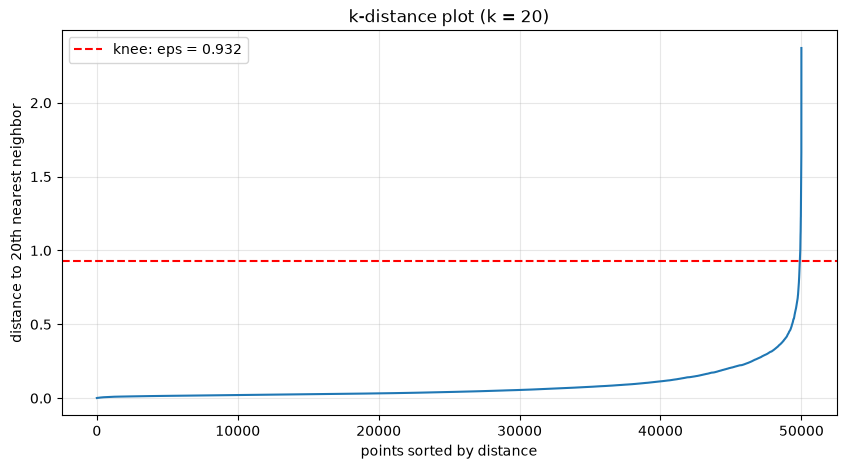

In [11]:
from sklearn.neighbors import NearestNeighbors
from kneed import KneeLocator
min_samples = 20
nn = NearestNeighbors(n_neighbors=min_samples).fit(X_sample)
distances, _ = nn.kneighbors(X_sample)
k_dist = np.sort(distances[:, -1])

knee = KneeLocator(range(len(k_dist)), k_dist, curve="convex", direction="increasing")
eps_knee = k_dist[knee.knee]
print(f"eps pishnahadi az zanoo: {eps_knee:.3f}")

plt.figure(figsize=(10, 5))
plt.plot(k_dist)
plt.axhline(eps_knee, color="red", linestyle="--", label=f"knee: eps = {eps_knee:.3f}")
plt.title(f"k-distance plot (k = {min_samples})")
plt.xlabel("points sorted by distance")
plt.ylabel(f"distance to {min_samples}th nearest neighbor")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

<div dir="rtl">

## ۳. امتحان eps های مختلف

خوشه‌ای رو معنادار حساب کردیم که حداقل ۱ درصد نمونه یعنی ۵۰۰ نقطه رو داشته باشه!! یک خوشه ۲۰ نقطه‌ای از ۵۰ هزار نقطه معنادار نیست.

</div>

In [12]:
eps_values = [0.02, 0.03, 0.05, 0.075, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5]
big_limit = int(len(sample) * 0.01)
rows = []
for eps in eps_values:
    labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_sample)
    sizes = pd.Series(labels[labels != -1]).value_counts()
    noise = (labels == -1).sum()

    rows.append({
        "eps": eps,
        "clusters": len(sizes),
        "big_clusters": (sizes >= big_limit).sum(),
        "largest_%": round(sizes.max() / len(sample) * 100, 1) if len(sizes) else 0,
        "noise_count": noise,
        "noise_%": round(noise / len(sample) * 100, 2),
    })
    print(f"eps={eps} anjam shod")

eps_results = pd.DataFrame(rows)
eps_results

eps=0.02 anjam shod
eps=0.03 anjam shod
eps=0.05 anjam shod
eps=0.075 anjam shod
eps=0.1 anjam shod
eps=0.15 anjam shod
eps=0.2 anjam shod
eps=0.25 anjam shod
eps=0.3 anjam shod
eps=0.4 anjam shod
eps=0.5 anjam shod


,eps,clusters,big_clusters,largest_%,noise_count,noise_%
0,0.020,123,3,12.5,35526,71.05
1,0.030,109,5,26.6,26632,53.26
2,0.050,94,7,40.5,17987,35.97
3,0.075,77,8,44.7,11933,23.87
4,0.100,58,9,45.7,8795,17.59
5,0.150,51,11,47.1,5410,10.82
6,0.200,34,8,66.3,3347,6.69
7,0.250,23,4,79.4,2038,4.08
8,0.300,12,2,87.4,1296,2.59
9,0.400,11,2,95.3,530,1.06


<div dir="rtl">

## ۴. جست‌وجوی دقیق

در جست‌وجوی اول eps برابر ۰.۰۲ هم ۳ خوشه داشت ولی ۷۱ درصد داده Noise بود و قابل قبول نیست. بازه درست بین ۰.۲۵ و ۰.۳ بود که Noise فقط ۳ تا ۴ درصد است. این بازه رو با گام ۰.۰۰۵ دقیق‌تر بررسی کردیم.

</div>

In [13]:
fine_eps = np.round(np.arange(0.25, 0.305, 0.005), 3)
rows = []
for eps in fine_eps:
    labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_sample)
    sizes = pd.Series(labels[labels != -1]).value_counts()
    noise = (labels == -1).sum()
    big = sizes[sizes >= big_limit]

    rows.append({
        "eps": eps,
        "clusters": len(sizes),
        "big_clusters": len(big),
        "big_sizes_%": list((big / len(sample) * 100).round(1)),
        "noise_count": noise,
        "noise_%": round(noise / len(sample) * 100, 2),
    })

fine_results = pd.DataFrame(rows)
fine_results

KeyboardInterrupt: 

<div dir="rtl">

## ۵. اثر eps

با بزرگ شدن eps شعاع همسایگی بزرگ‌تر می‌شود. پس نقطه‌های بیشتری همسایه کافی پیدا می‌کنند و Noise مرتب کم می‌شود.
تعداد خوشه‌های معنادار اول زیاد و بعد کم می‌شود. با eps خیلی کوچک فقط هسته‌های خیلی متراکم خوشه می‌شوند. با eps متوسط هر شهر بزرگ خوشه جدا می‌شود. با eps بزرگ شهرها به هم می‌چسبند تا همه یک خوشه شوند.

</div>

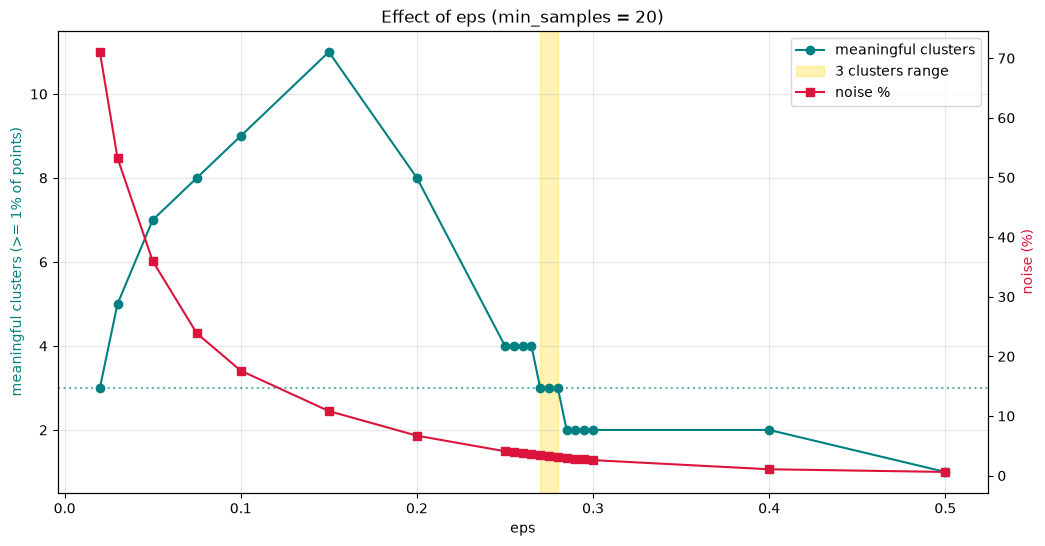

In [ ]:
all_results = pd.concat([eps_results, fine_results], ignore_index=True)
all_results = all_results.drop_duplicates("eps").sort_values("eps")

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(all_results["eps"], all_results["big_clusters"], marker="o", color="teal", label="meaningful clusters")
ax1.axhline(3, color="teal", linestyle=":", alpha=0.6)
ax1.set_xlabel("eps")
ax1.set_ylabel("meaningful clusters (>= 1% of points)", color="teal")

ax2 = ax1.twinx()
ax2.plot(all_results["eps"], all_results["noise_%"], marker="s", color="crimson", label="noise %")
ax2.set_ylabel("noise (%)", color="crimson")

ax1.axvspan(0.27, 0.28, color="gold", alpha=0.3, label="3 clusters range")
ax1.set_title(f"Effect of eps (min_samples = {min_samples})")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.88))
ax1.grid(alpha=0.3)
plt.show()

<div dir="rtl">

## ۶. خوشه‌ها با eps برابر ۰.۲۷۵

وسط بازه ۰.۲۷ تا ۰.۲۸ رو انتخاب کردیم تا تغییر کوچک داده نتیجه رو عوض نکنه

</div>

In [ ]:
best_eps = 0.275
sample["cluster"] = DBSCAN(eps=best_eps, min_samples=min_samples).fit_predict(X_sample)

big_ids = sample["cluster"].value_counts().loc[lambda s: s >= big_limit].index.drop(-1, errors="ignore")

summary = sample[sample["cluster"].isin(big_ids)].groupby("cluster").agg(
    tedad=("cluster", "size"),
    median_gheymat=("unified_price", "median"),
    shahr_ha=("city_slug", lambda s: ", ".join(s.value_counts().head(3).index)),
)
summary["darsad"] = (summary["tedad"] / len(sample) * 100).round(1)
summary["median_gheymat"] = (summary["median_gheymat"] / 1e9).round(2)
summary.sort_values("tedad", ascending=False)

,tedad,median_gheymat,shahr_ha,darsad
cluster,,,,
0,39955,2.45,"tehran, karaj, isfahan",79.9
1,3456,2.20,"shiraz, ahvaz, sadra",6.9
2,2999,2.20,"mashhad, neyshabur, golbahar-city",6.0


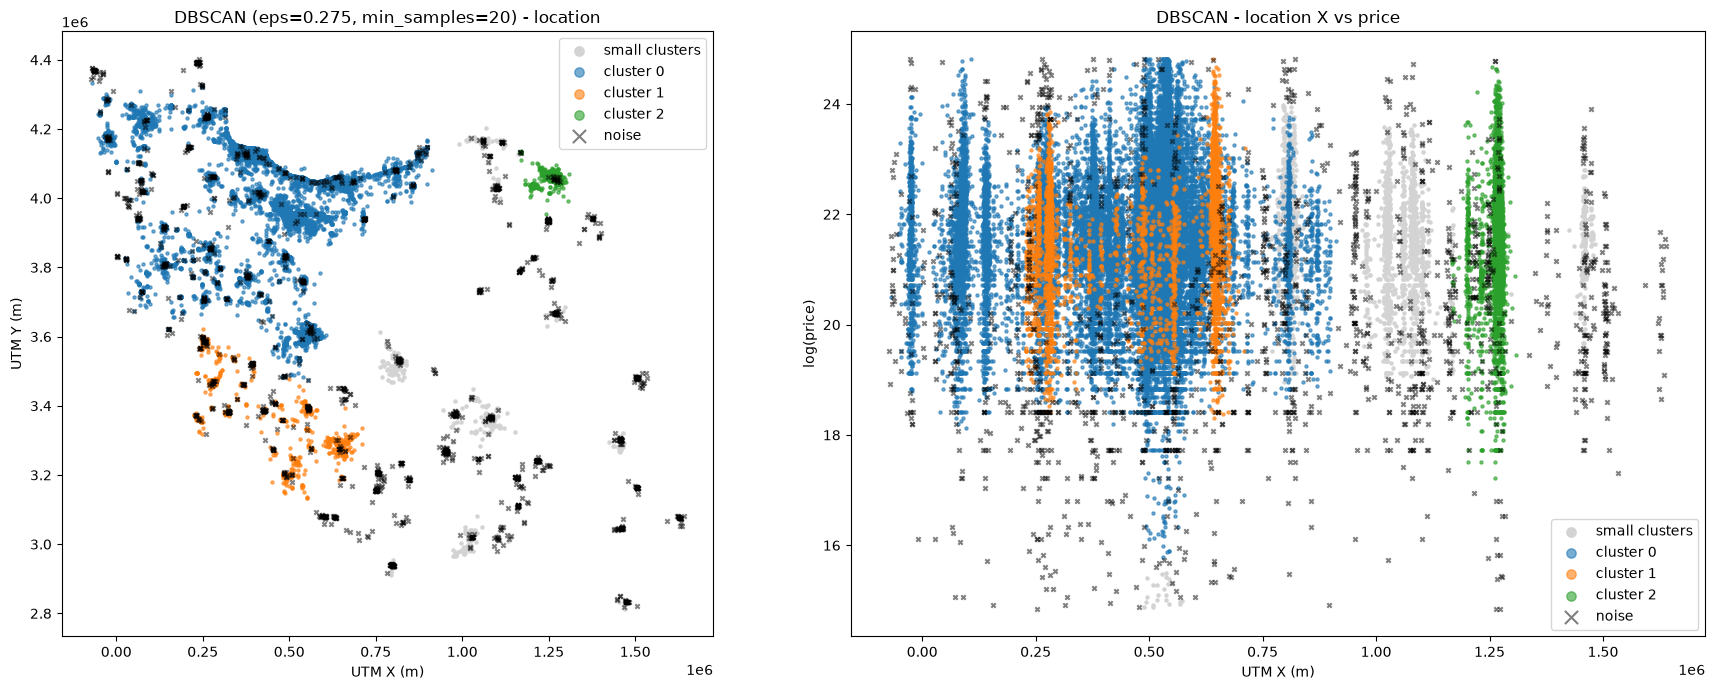

In [ ]:
colors = {cid: c for cid, c in zip(big_ids, ["tab:blue", "tab:orange", "tab:green"])}

big = sample[sample["cluster"].isin(big_ids)]
small = sample[~sample["cluster"].isin(big_ids) & (sample["cluster"] != -1)]
noise = sample[sample["cluster"] == -1]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, y_col, y_label in [(axes[0], "location_utm_y", "UTM Y (m)"), (axes[1], "log_price", "log(price)")]:
    ax.scatter(small["location_utm_x"], small[y_col], c="lightgray", s=5, label="small clusters")
    for cid, color in colors.items():
        part = big[big["cluster"] == cid]
        ax.scatter(part["location_utm_x"], part[y_col], c=color, s=5, alpha=0.6, label=f"cluster {cid}")
    ax.scatter(noise["location_utm_x"], noise[y_col], c="black", marker="x", s=10, alpha=0.5, label="noise")
    ax.set_xlabel("UTM X (m)")
    ax.set_ylabel(y_label)
    ax.legend(markerscale=3)

axes[0].set_title(f"DBSCAN (eps={best_eps}, min_samples={min_samples}) - location")
axes[0].set_aspect("equal")
axes[1].set_title("DBSCAN - location X vs price")

plt.tight_layout()
plt.show()

<div dir="rtl">

## نتیجه

با min_samples برابر ۲۰ بازه eps بین ۰.۲۷ و ۰.۲۸ دقیقا ۳ خوشه معنادار با حدود ۳ درصد Noise می‌دهد. پیشنهاد ما eps برابر ۰.۲۷۵ است.

سه خوشه سه منطقه جغرافیایی ایران هستند. خوشه اول مرکز و شمال و شمال غرب است مثل تهران و کرج و اصفهان و سواحل خزر و ۸۰ درصد داده رو پوششش میده. خوشه دوم جنوب غرب است مثل شیراز و اهواز. خوشه سوم شمال شرق است یعنی مشهد و اطرافش.

میانه قیمت سه خوشه تقریبا یکی است و در نمودار قیمت هم کاملا روی هم افتاده‌. یعنی خوشه‌ها فقط با مکان از هم جدا شدن. داخل هر منطقه همه نوع قیمتی هست و قیمت‌ها پیوسته پخشن پس DBSCAN در بعد قیمت مرزی پیدا نمی‌کند. ولی بین مناطق کویر و فاصله زیاد این مرز را می‌سازد.

خوشه‌ها متوازن نیستند چون DBSCAN بر اساس تراکم کار می‌کند و مثل K-means داده را مساوی تقسیم نمی‌کند.

</div>